In [ ]:
from __future__ import annotations

import warnings
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df = cancer.frame.copy()
TARGET = "target"
TARGET_MAP = {0: "malignant", 1: "benign"}
df["_target_name"] = df[TARGET].map(TARGET_MAP)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

HUE_ORDER = ["malignant", "benign"]  # consistent plot ordering
TOP_K = 6  # for pairplots and ridge plots
WRAP = 4  # facet wrap (columns) for grids
HEIGHT_SMALL = 2.0  # facet height for small panels
HEIGHT_MED = 2.5

# Toggle heavy plots if you like
DO_PAIRPLOT = True
DO_CLUSTERMAP = True
DO_JOINTPLOTS = True


def numeric_cols(frame: pd.DataFrame, exclude: Optional[List[str]] = None) -> List[str]:
    exclude = set(exclude or [])
    return [
        c
        for c in frame.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(frame[c])
    ]


def rank_by_mutual_info(
    frame: pd.DataFrame, target: str, random_state: int = 42
) -> pd.Series:
    cols = numeric_cols(frame, exclude=[target, "_target_name"])
    X = frame[cols]
    y = frame[target].astype(int).to_numpy()
    mi = mutual_info_classif(X, y, random_state=random_state, discrete_features=False)
    return pd.Series(mi, index=cols).sort_values(ascending=False)

### Figure 1: Displot - False vs "value" - (hue = "_target_name") - [Faceted: col = "feature"]

**Objective.** Summarise the relationship/pattern using `sns.displot` on `long`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `"value"` and `False`? Do groups defined by `"_target_name"` differ meaningfully?*

**Visual design.** This figure uses `sns.displot` with bins = 30. Axes map: `x = "value"`, `y = False`, `hue = "_target_name"`, `col = "feature"`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices (bins = 30). If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `"_target_name"` further, or replace with a more appropriate geometry if assumptions are violated.


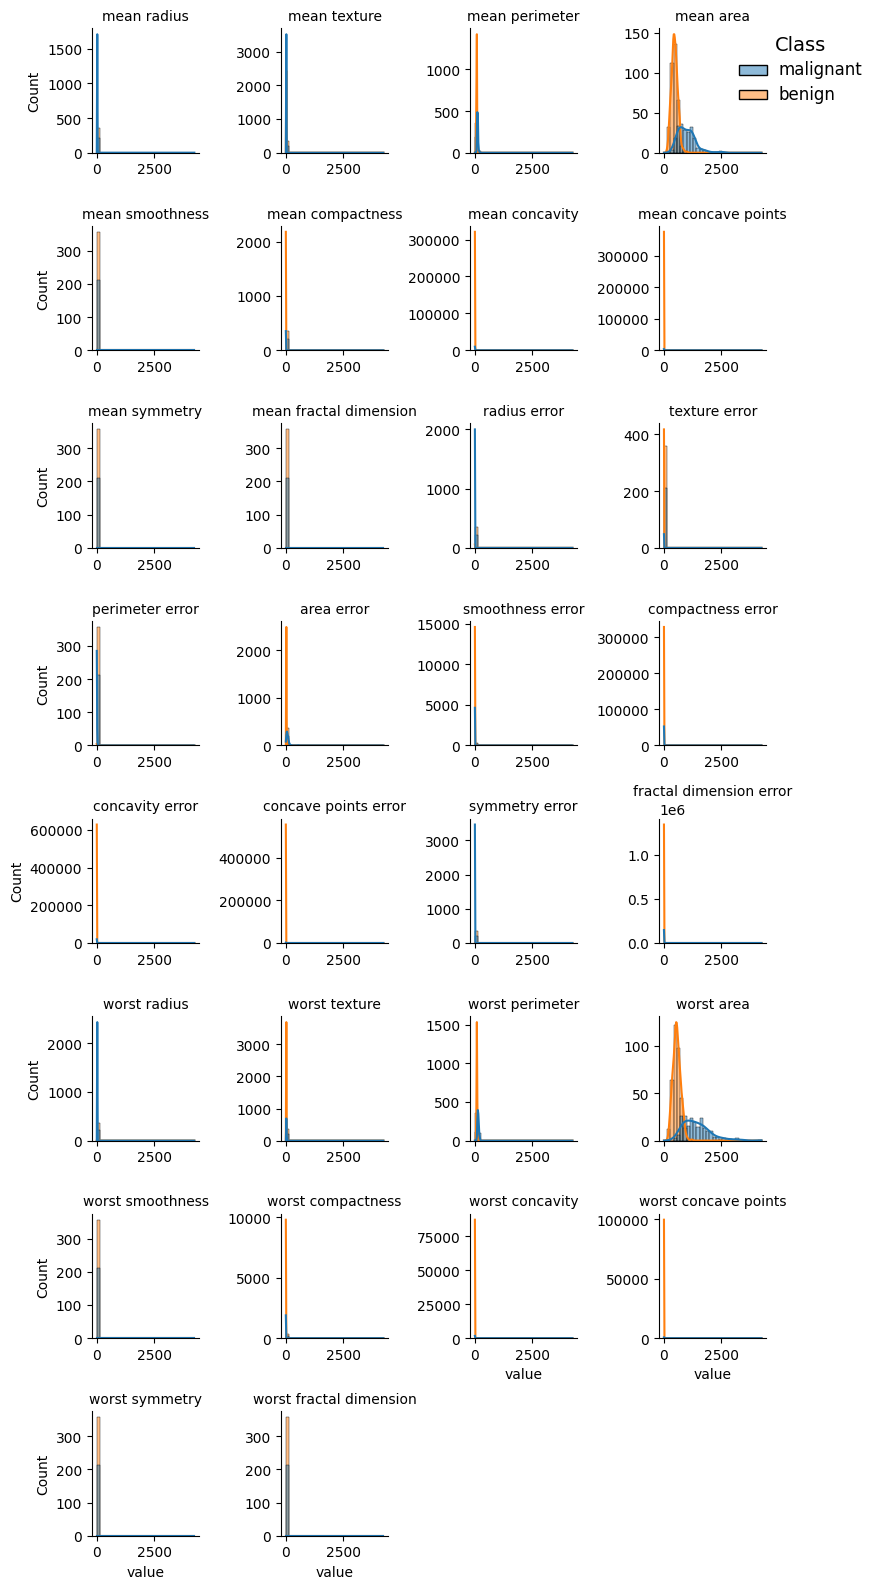

In [ ]:
long = df.melt(
    id_vars=["_target_name"],
    value_vars=numeric_cols(df, exclude=[TARGET, "_target_name"]),
    var_name="feature",
    value_name="value",
)
g = sns.displot(
    data=long,
    x="value",
    hue="_target_name",
    col="feature",
    col_wrap=WRAP,
    bins=30,
    kde=True,
    common_norm=False,
    facet_kws=dict(sharex=False, sharey=False),
    height=HEIGHT_SMALL,
    hue_order=HUE_ORDER,
)
g.set_titles("{col_name}")
g.legend.set_title("Class")
g.legend.set_bbox_to_anchor((0.95, 0.95))  # Position legend in upper right
g.legend.get_title().set_fontsize(14)  # Make title more prominent
for text in g.legend.get_texts():
    text.set_fontsize(12)  # Make legend text larger
plt.show()

### Figure 2: Displot - False vs "value" - (hue = "_target_name") - [Faceted: col = "feature"]

**Objective.** Summarise the relationship/pattern using `sns.displot` on `long`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `"value"` and `False`? Do groups defined by `"_target_name"` differ meaningfully?*

**Visual design.** This figure uses `sns.displot` with kind = "ecdf". Axes map: `x = "value"`, `y = False`, `hue = "_target_name"`, `col = "feature"`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `"_target_name"` further, or replace with a more appropriate geometry if assumptions are violated.


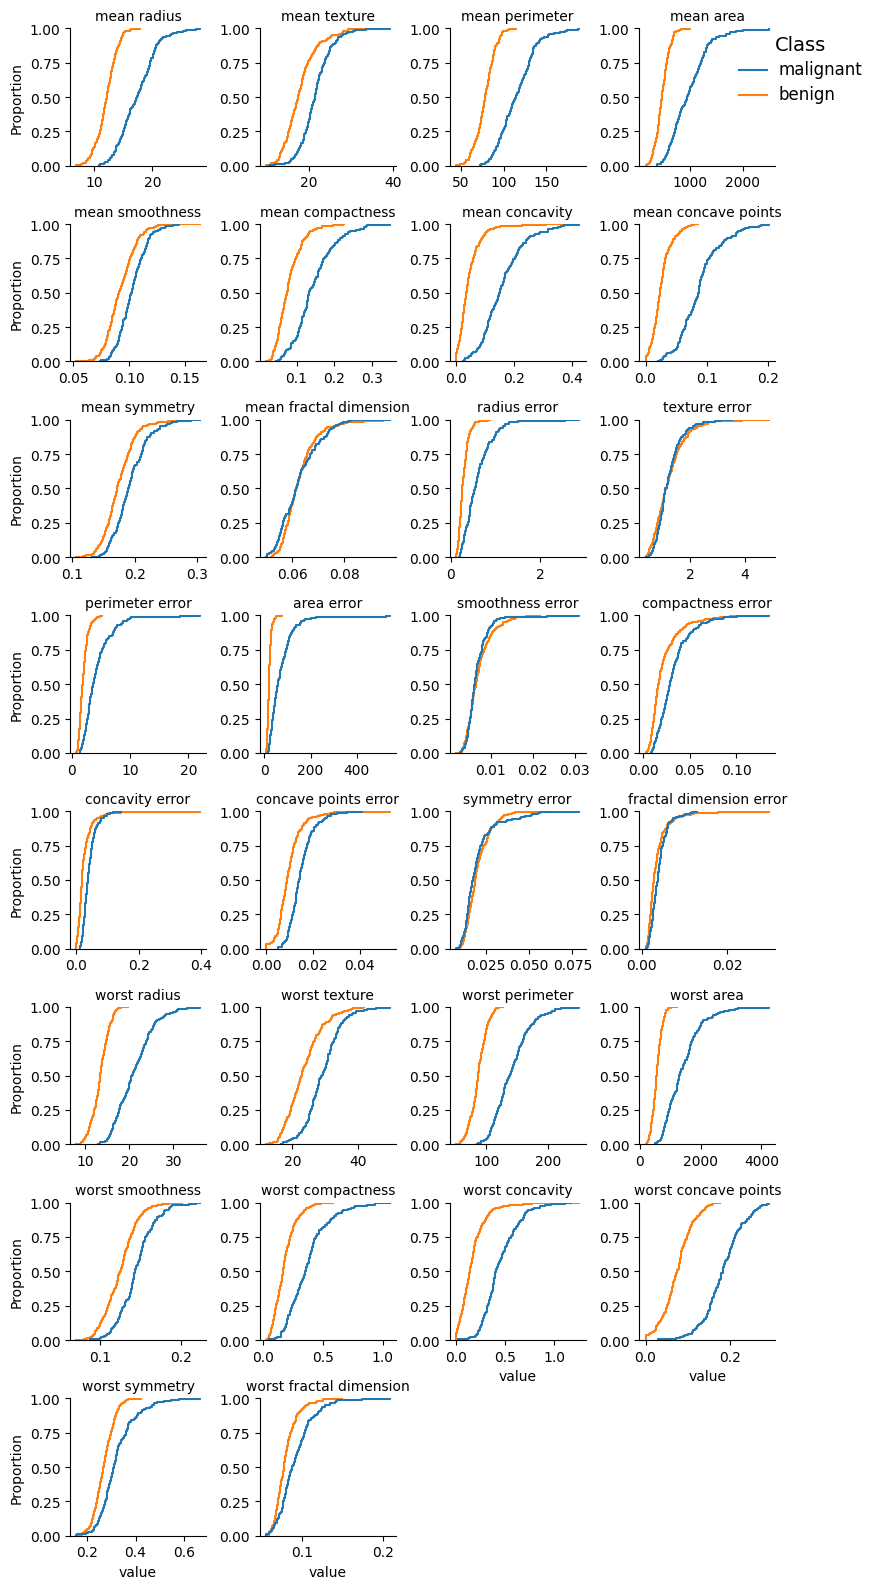

In [ ]:
g = sns.displot(
    data=long,
    x="value",
    hue="_target_name",
    col="feature",
    col_wrap=WRAP,
    kind="ecdf",
    facet_kws=dict(sharex=False, sharey=False),
    height=HEIGHT_SMALL,
    hue_order=HUE_ORDER,
)

g.set_titles("{col_name}")
g.legend.set_title("Class")
g.legend.set_bbox_to_anchor((0.95, 0.95))
g.legend.get_title().set_fontsize(14)
for text in g.legend.get_texts():
    text.set_fontsize(12)

plt.show()

### Figure 3: Facetgrid - False vs False - (hue = "_target_name") - [Faceted: col = "feature"]

**Objective.** Summarise the relationship/pattern using `sns.FacetGrid` on `dataframe`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `False` and `False`? Do groups defined by `"_target_name"` differ meaningfully?*

**Visual design.** This figure uses `sns.FacetGrid` with Default seaborn parameters. Axes map: `x = False`, `y = False`, `hue = "_target_name"`, `col = "feature"`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `"_target_name"` further, or replace with a more appropriate geometry if assumptions are violated.


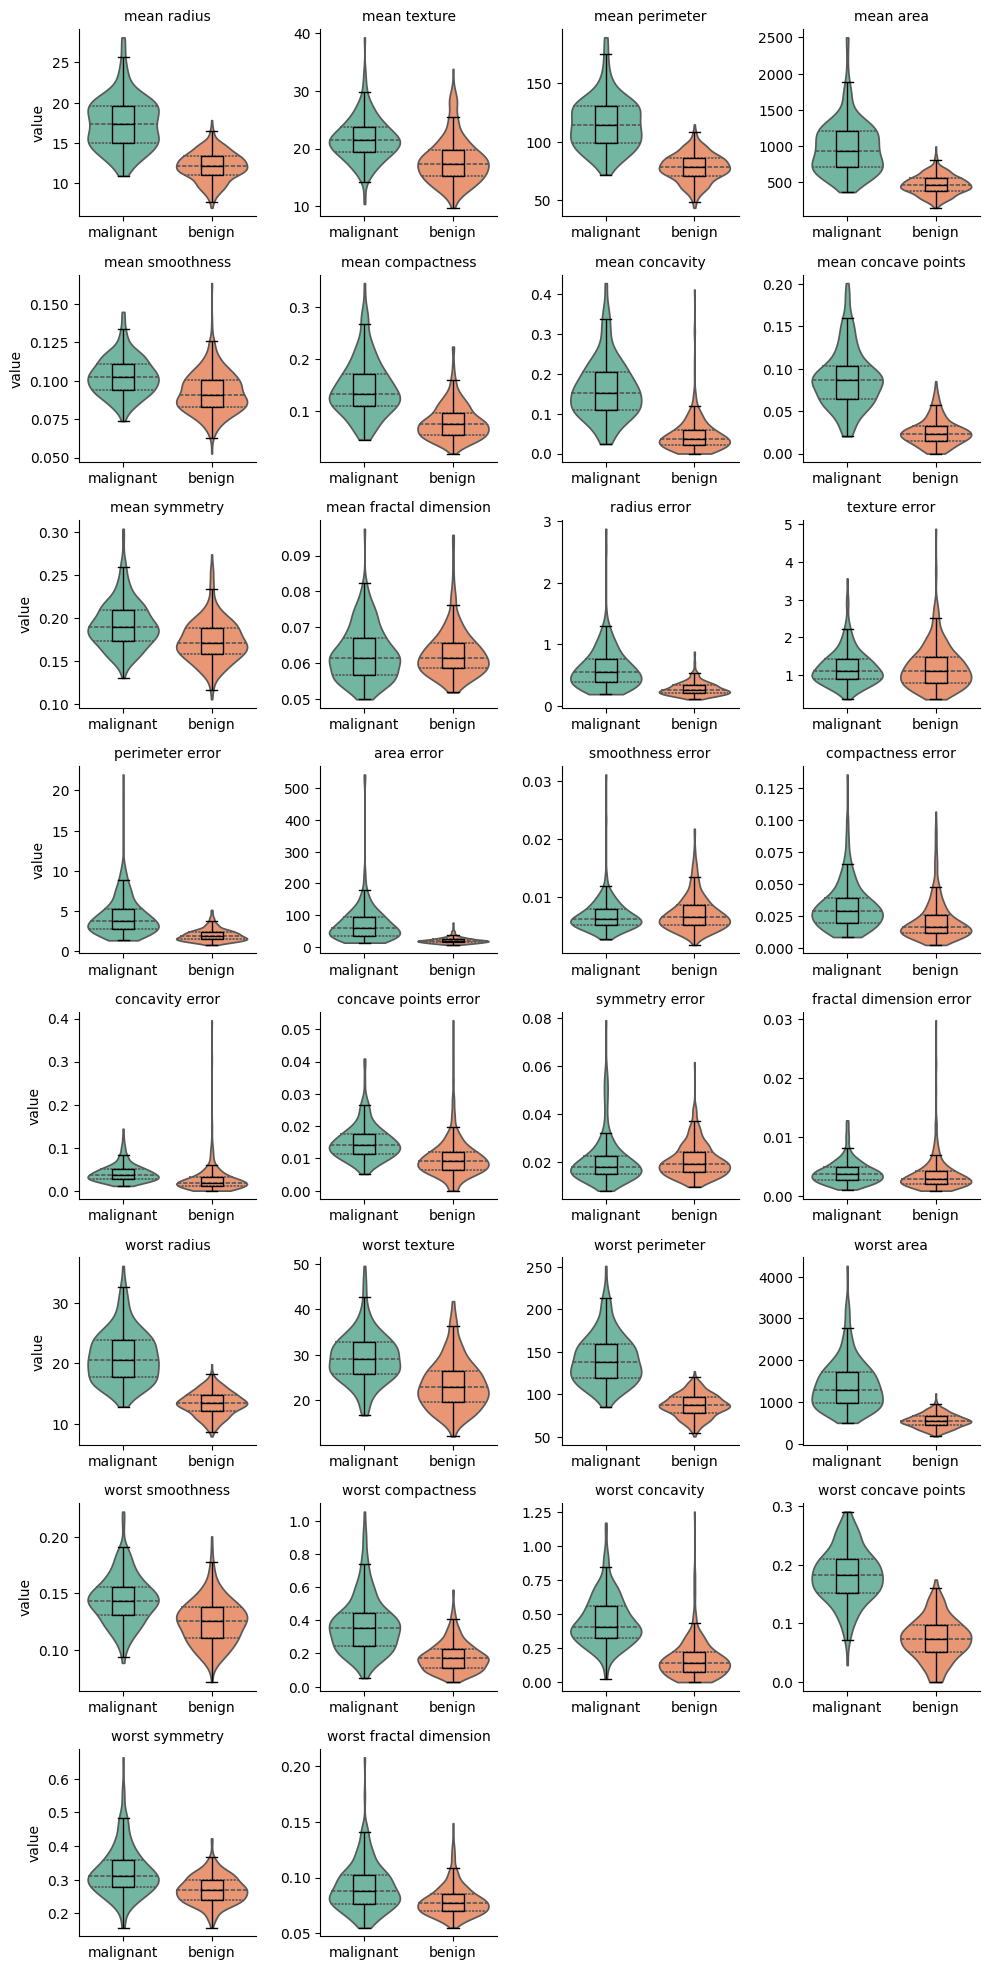

In [ ]:
g = sns.FacetGrid(
    long, col="feature", col_wrap=WRAP, height=HEIGHT_MED, sharex=False, sharey=False
)
g.map_dataframe(
    sns.violinplot,
    x="_target_name",
    y="value",
    hue="_target_name",
    dodge=False,
    cut=0,
    inner="quartile",
    order=HUE_ORDER,
    hue_order=HUE_ORDER,
    palette=sns.color_palette("Set2", n_colors=len(HUE_ORDER)),  # avoid FutureWarning
)
g.map_dataframe(
    sns.boxplot,
    x="_target_name",
    y="value",
    showcaps=True,
    boxprops={"facecolor": "none"},
    showfliers=False,
    whiskerprops={"linewidth": 1.0},
    width=0.25,
    order=HUE_ORDER,
    color="black",
)
for ax in g.axes.flat:
    ax.set_xlabel("")
g.set_titles("{col_name}")

plt.show()

In [ ]:
num = df[numeric_cols(df, exclude=[TARGET, "_target_name"])]
corr = num.corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

### Figure 4: Figure

**Objective.** Summarise the relationship/pattern using `plt.figure` on `dataframe`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `None` and `None`? Do groups defined by `None` differ meaningfully?*

**Visual design.** This figure uses `plt.figure` with Default seaborn parameters. Axes map: `x = ...`, `y = ...`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `None` further, or replace with a more appropriate geometry if assumptions are violated.


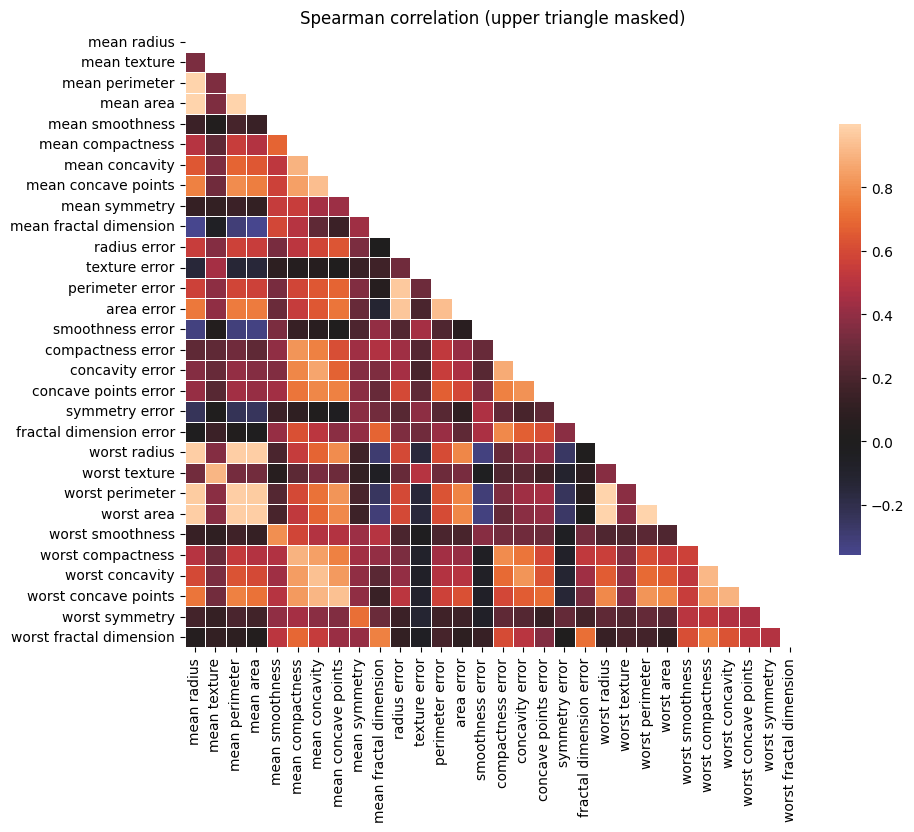

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, center=0.0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}
)
plt.title("Spearman correlation (upper triangle masked)")
plt.show()

# Hierarchical Structure Discovery: Advanced Correlation Clustering

The correlation clustermap represents a sophisticated evolution of our correlation analysis, employing hierarchical clustering algorithms to reveal the latent structure within our feature correlation matrix. This approach transforms a simple correlation visualization into a powerful tool for understanding the natural groupings and relationships that exist within our high-dimensional feature space.

Hierarchical clustering operates on the principle of agglomerative linkage, beginning with each feature as its own cluster and iteratively merging the most similar clusters based on their correlation profiles. The algorithm uses the correlation distance (1 - |correlation|) as a dissimilarity measure, meaning that features with high positive or negative correlations are considered similar and will cluster together. The resulting dendrogram traces this merger process, with the height of each branch indicating the dissimilarity at which clusters were joined - lower joins represent more similar feature groups.

The reordering of rows and columns based on this clustering reveals patterns that would be invisible in an alphabetically ordered correlation matrix. Features that cluster together often share underlying biological or measurement characteristics, providing insights into the redundancy structure of our dataset. For instance, we might expect geometric features like area, perimeter, and radius to cluster together, while texture-based measurements form their own distinct group. These natural groupings can inform dimensionality reduction strategies, suggesting which features might be combined or which ones might be redundant.

From a statistical modeling perspective, the clustermap guides feature selection decisions by highlighting groups of highly intercorrelated variables. Within each cluster, we might choose to retain only the most informative representative feature, or alternatively, create composite features that capture the shared information across cluster members. The dendrogram structure also suggests natural breakpoints for feature grouping - cutting the tree at different heights produces different numbers of feature clusters, each representing a different level of granularity in our feature space organization.

### Figure 5: Clustermap - Distribution of 1

**Objective.** Summarise the relationship/pattern using `sns.clustermap` on `dataframe`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `1` and `1`? Do groups defined by `None` differ meaningfully?*

**Visual design.** This figure uses `sns.clustermap` with Default seaborn parameters. Axes map: `x = ...`, `y = 1`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `None` further, or replace with a more appropriate geometry if assumptions are violated.


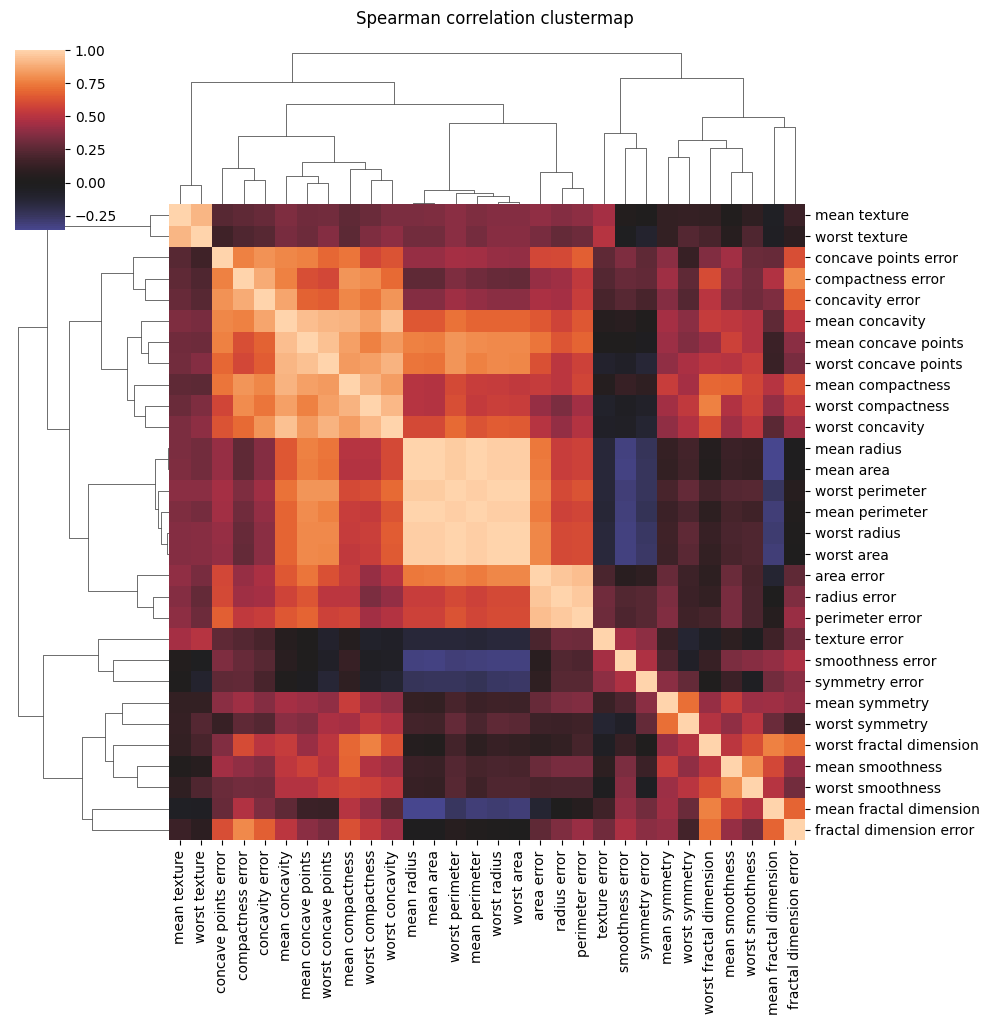

In [ ]:
if DO_CLUSTERMAP:
    sns.clustermap(corr, center=0.0, figsize=(10, 10))
    plt.suptitle("Spearman correlation clustermap", y=1.02)
    plt.show()

# Multivariate Exploration: Pairwise Relationships Among Elite Features

The pairplot matrix represents our transition from univariate to multivariate analysis, focusing specifically on the features that exhibit the highest mutual information with our target variable. Mutual information, an information-theoretic measure derived from entropy concepts, quantifies the amount of information one variable provides about another, capturing both linear and non-linear dependencies that simple correlation coefficients might miss.

By restricting our analysis to the top-ranked features, we focus our attention on the most informative dimensions of our feature space - those that provide the greatest discriminatory power between malignant and benign cases. This selection strategy is rooted in the principle of dimensional economy: rather than attempting to visualize all possible pairwise relationships (which would require 435 plots for 30 features), we concentrate on the relationships most likely to reveal meaningful patterns for classification.

Each off-diagonal subplot reveals the bivariate distribution of two features, with color-coding that allows us to assess class separability in two-dimensional space. Linear separability appears as clear clustering of colors with minimal overlap, while more complex patterns might suggest the need for non-linear decision boundaries. The diagonal elements show univariate kernel density estimates for each selected feature, providing a refined view of the distributional differences we observed in our earlier analysis.

The strategic value of this visualization lies in its ability to reveal interaction effects and higher-dimensional structure that univariate analyses cannot capture. Two features that individually show modest class separation might, when combined, create powerful discriminatory boundaries. Conversely, features that appear promising individually might show redundant information when viewed together, suggesting opportunities for dimensionality reduction. The corner layout eliminates redundant plots while preserving all unique pairwise comparisons, optimizing the information density of our visualization space.

### Figure 6: Pairplot - Distribution of 0 - (hue = "_target_name") - [Faceted: col = len]

**Objective.** Summarise the relationship/pattern using `sns.pairplot` on `dataframe`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `0` and `0`? Do groups defined by `"_target_name"` differ meaningfully?*

**Visual design.** This figure uses `sns.pairplot` with kind = "kde". Axes map: `x = ...`, `y = 0`, `hue = "_target_name"`, `col = len`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `"_target_name"` further, or replace with a more appropriate geometry if assumptions are violated.


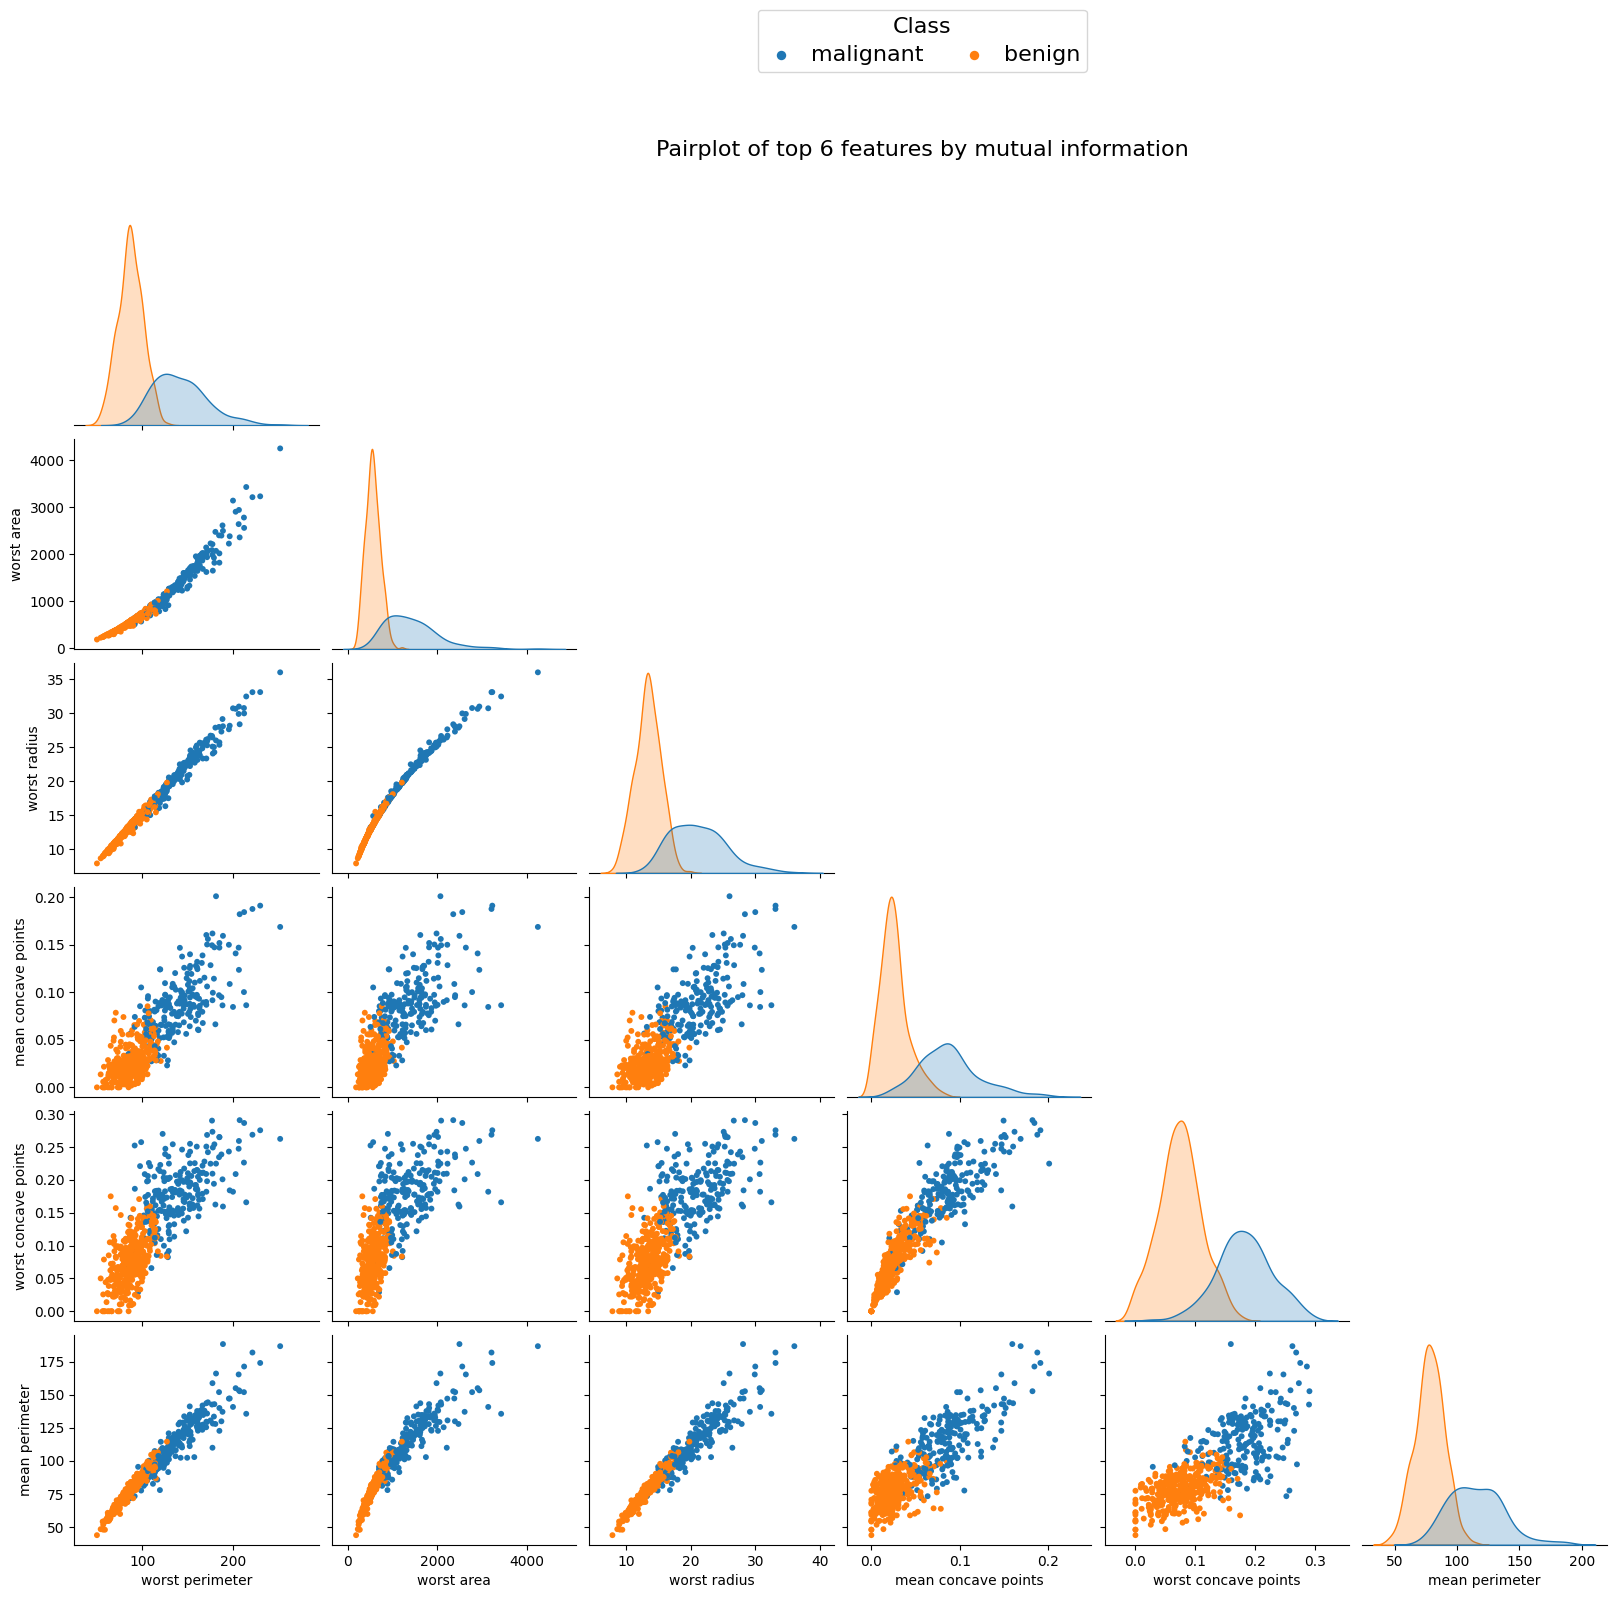

In [ ]:
mi = rank_by_mutual_info(df, TARGET)
top_cols = mi.head(TOP_K).index.tolist()

if DO_PAIRPLOT:
    g = sns.pairplot(
        df[top_cols + ["_target_name"]],
        hue="_target_name",
        hue_order=HUE_ORDER,
        diag_kind="kde",
        corner=True,
        plot_kws={"s": 18, "linewidth": 0},
        diag_kws={"fill": True},
    )

    # Remove seaborn's auto-legend if present (handles different versions)
    for attr in ("_legend", "legend"):
        leg = getattr(g, attr, None)
        if leg is not None:
            try:
                leg.remove()
            except Exception:
                pass

    g.add_legend(
        title="Class",
        label_order=HUE_ORDER,
        bbox_to_anchor=(0.5, 1.02),
        loc="lower center",
        ncol=len(HUE_ORDER),
        frameon=True,
        fontsize=12,
        title_fontsize=13,
        markerscale=1.6,
    )
    g.fig.subplots_adjust(top=0.88)

    # Grab the actual mpl.Legend object and fine-tune
    leg = g._legend
    if hasattr(leg, "get_title"):
        leg.get_title().set_fontsize(16)
    for txt in leg.get_texts():
        txt.set_fontsize(16)
    try:
        leg.set_draggable(False)  # ignore on older Matplotlib
    except Exception:
        pass

    # Make room for the legend and title
    g.fig.subplots_adjust(right=0.86, top=0.93)
    plt.suptitle(
        f"Pairplot of top {TOP_K} features by mutual information", y=0.98, fontsize=16
    )
    plt.show()

# Bivariate Density Landscapes: Joint Distribution Analysis

The joint plots provide an intensive examination of bivariate relationships by combining contour-based density estimation with marginal distribution analysis. Unlike the pairplot's scatter-based approach, these density contours reveal the probabilistic landscape of feature combinations, showing not just where data points exist, but the relative likelihood of different feature value combinations within each class.

The theoretical foundation of joint density estimation rests on the concept that two-dimensional distributions can reveal patterns invisible in either marginal distribution alone. By using kernel density estimation in two dimensions, we construct a smooth probability surface that represents the joint likelihood of observing specific combinations of feature values. The contour lines connect points of equal probability density, creating a topographic map of the data distribution where peaks represent the most common feature combinations and valleys indicate rare or absent combinations.

Each joint plot pairs one of our top features with the highest-ranking feature (serving as an "anchor"), creating a systematic exploration of how the most informative feature relates to each of the other top-ranking features. This anchor-based approach allows us to understand how the single most discriminative feature interacts with other important variables, potentially revealing synergistic relationships that could enhance classification performance.

The marginal distributions flanking each joint plot provide crucial context by showing the univariate densities of each feature. When the joint distribution shows patterns that differ significantly from what would be expected from the marginals alone (such as curved or diagonal density ridges), it indicates significant correlation or interaction effects. The separation of class-specific contours in the joint space reveals the effectiveness of feature combinations for classification - well-separated contour clusters suggest that these feature pairs provide strong discriminatory power, while overlapping contours indicate areas of classification ambiguity that might require additional features or more sophisticated modeling approaches.

### Figure 7: Jointplot - feat vs anchor - (hue = "_target_name")

**Objective.** Summarise the relationship/pattern using `sns.jointplot` on `df`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `anchor` and `feat`? Do groups defined by `"_target_name"` differ meaningfully?*

**Visual design.** This figure uses `sns.jointplot` with kind = "kde". Axes map: `x = anchor`, `y = feat`, `hue = "_target_name"`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `"_target_name"` further, or replace with a more appropriate geometry if assumptions are violated.


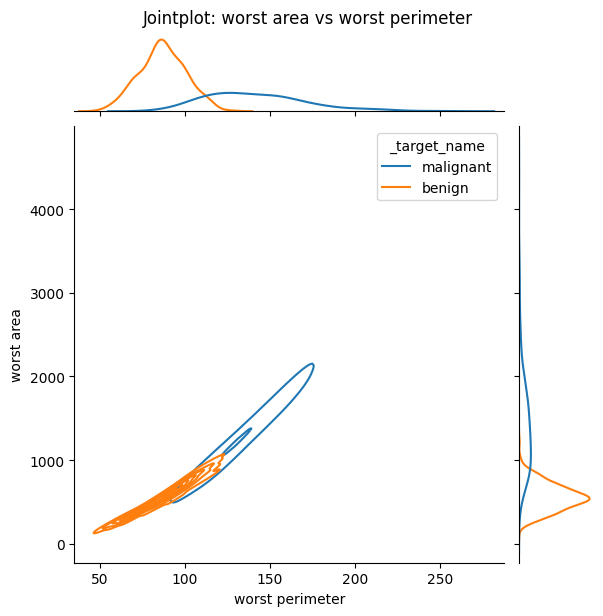

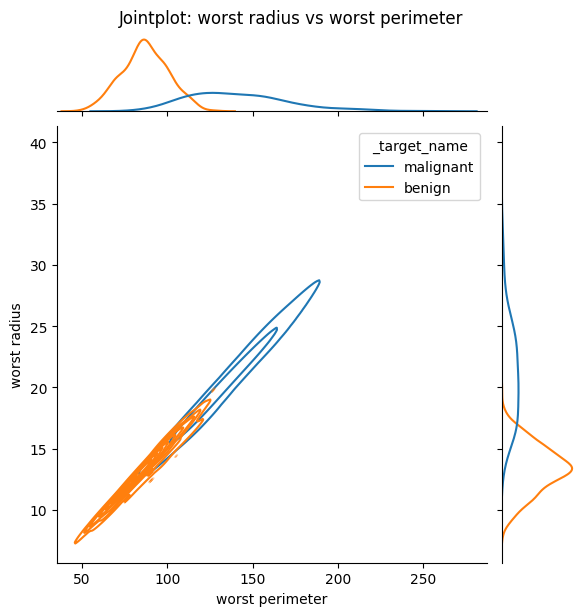

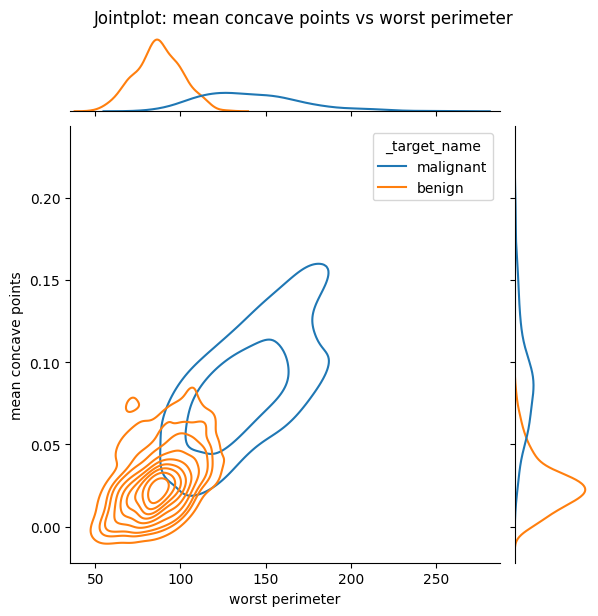

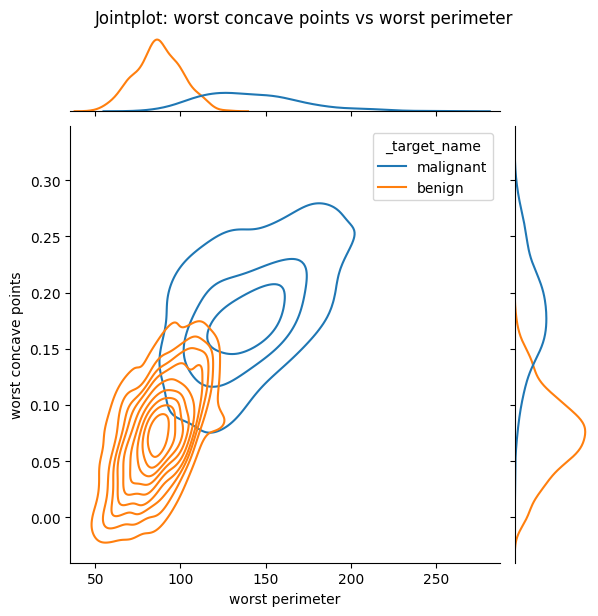

In [ ]:
# Jointplots of each top feature vs the strongest anchor
if DO_JOINTPLOTS:
    anchor = top_cols[0]
    for feat in top_cols[1 : min(len(top_cols), 5)]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            g = sns.jointplot(
                data=df,
                x=anchor,
                y=feat,
                hue="_target_name",
                hue_order=HUE_ORDER,
                kind="kde",
            )
            g.fig.suptitle(f"Jointplot: {feat} vs {anchor}", y=1.02)
            plt.show()

# Comparative Density Analysis: Ridge Plots for Feature Assessment

Ridge plots, also known as joy plots, provide an elegant solution to the challenge of comparing multiple distributions simultaneously while maintaining visual clarity and interpretive power. This visualization technique transforms our top-ranked features into a series of overlapping density curves, creating a comprehensive view of distributional differences that would be difficult to perceive in traditional side-by-side comparisons.

The statistical foundation of ridge plots lies in their ability to preserve the complete shape information of each distribution while enabling direct visual comparison across features and classes. Unlike histograms or box plots, which reduce distributions to summary statistics or discrete bins, ridge plots maintain the continuous nature of our kernel density estimates. The overlapping design allows for immediate assessment of distributional overlap between classes - a critical factor in determining feature effectiveness for classification tasks.

The vertical stacking of features creates a natural ranking system, with the most informative features positioned prominently and allowing for quick identification of the strongest discriminatory patterns. The bandwidth adjustment parameter in the kernel density estimation controls the smoothness of each curve, balancing between revealing fine-grained distributional details and maintaining overall pattern clarity. This parameter choice is particularly important for medical data, where both subtle distributional shifts and robust pattern recognition are crucial.

From a machine learning interpretation perspective, ridge plots excel at revealing the nature of class separability for each feature. Features showing complete separation between class curves represent ideal candidates for threshold-based classification rules, while partially overlapping curves indicate the degree of classification ambiguity that any algorithm will face. The relative positioning of peaks reveals whether classes differ primarily in central tendency (shifted peaks) or in distributional shape (different peak widths or skewness), information that can guide the selection of appropriate modeling approaches and inform our understanding of the underlying biological processes that distinguish malignant from benign tissue.

### Figure 8: Facetgrid - False vs False - (hue = "_target_name") - [Faceted: row = "feature"]

**Objective.** Summarise the relationship/pattern using `sns.FacetGrid` on `dataframe`. Specify what question this figure answers in this context, for example: *Is there a monotonic trend between `False` and `False`? Do groups defined by `"_target_name"` differ meaningfully?*

**Visual design.** This figure uses `sns.FacetGrid` with Default seaborn parameters. Axes map: `x = False`, `y = False`, `hue = "_target_name"`, `row = "feature"`. Ensure axis units and any transformations (e.g., log scale, standardisation) are stated explicitly.

**How to read.** Describe the expected pattern and how to compare groups. If faceted, compare within rows/columns first, then across facets to avoid misinterpretation.

**Quality checks.** Confirm sample sizes per group, handle outliers sensibly, and justify binning/aggregation choices. If overlap or overplotting is severe, add transparency or small jitter.

**Interpretation cues.** State the main finding in one line, with uncertainty where relevant (e.g., confidence intervals if shown). Avoid causal language.

**Next step.** Suggest the immediate next analysis - e.g., fit a simple model, stratify by `"_target_name"` further, or replace with a more appropriate geometry if assumptions are violated.


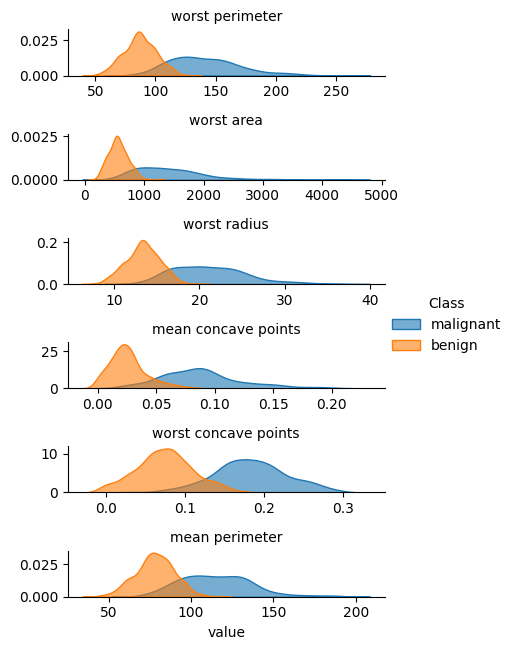

In [ ]:
long_top = df.melt(
    id_vars=["_target_name"],
    value_vars=top_cols,
    var_name="feature",
    value_name="value",
)
g = sns.FacetGrid(
    long_top,
    row="feature",
    hue="_target_name",
    hue_order=HUE_ORDER,
    aspect=4,
    height=1.1,
    sharex=False,
    sharey=False,
)
g.map(sns.kdeplot, "value", bw_adjust=0.9, fill=True, alpha=0.6)
for ax in g.axes.flat:
    ax.set_ylabel("")
g.add_legend(title="Class")
g.set_titles("{row_name}")
plt.show()